# Quick walkthrough

This tutorial walks through the central methods and arguments to build workflows for depositing particle fields onto structured grids. 

+ We will see how to deposit weights of particles drawn from the swiss role dataset onto a uniform 2D grid.
+ We will use both `isotropic` and `anisotropic` structures for direct comparison.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import smudgy as sm

np.random.seed(0)

In [ ]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

## Depositing a scalar field onto a grid

We will use particles drawn from the swiss role dataset in an open box (i.e. no `boxsize` parameter is necessary) and weights set to ones:

In [2]:
# Swiss roll parameters
height = 1.0
length = 5 * np.pi
noise  = 1.0

N = 50_000
weights = np.ones(N)

# Generate 2D Swiss roll dataset
t = length * (np.random.rand(N)) + 1.5 * np.pi  # t in [1.5pi, 3pi]
x = t * np.cos(t)
y = t * np.sin(t)

# Add noise
x += noise * np.random.randn(N)
y += noise * np.random.randn(N)

# Rescale to [0, 1]
X_swiss = np.vstack((x, y)).T
min_X = X_swiss.min(axis=0)
max_X = X_swiss.max(axis=0)
positions = (X_swiss - min_X) / (max_X - min_X + 1e-8)* 0.99

Let's inspect the particle distribution via a simple scatter plot:

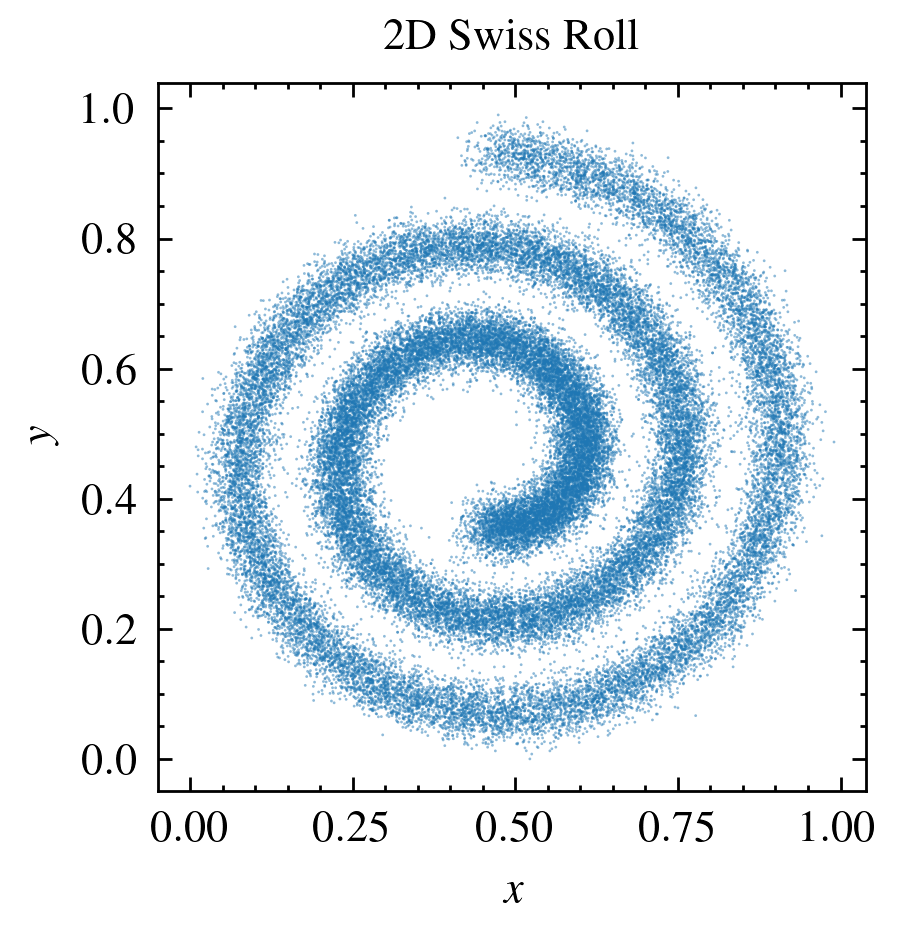

In [3]:
fig, ax = plt.subplots()
ax.scatter(positions[:, 0], positions[:, 1], edgecolors='none', s=1, alpha=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$y$', aspect='equal')
ax.set_title('2D Swiss Roll')
plt.show()

Then, we initialize a `PointCloud` instance and globally set the kernel to a cubic spline and the number of neighbors to use in computations to 32. The structure we do not fix for now as we want to use methods both with `isotropic` and `anisotropic` structures.

In [4]:
pc = sm.PointCloud(positions=positions,
                   weights=weights).\
    global_setup(kernel_name='cubic_spline',
                    num_neighbors=32)

[smudgy] Initialized 2d PointCloud with 50000 particles without periodicity
[smudgy] Set kernel globally to 'cubic_spline'
[smudgy] Set number of neighbors globally to 32


Next we compute the smoothing lengths and tensors, by passing the `isotropic` and `anisotropic` structure argument to the `compute_smoothing` method.

In [5]:
pc.compute_smoothing(structure='isotropic')
pc.compute_smoothing(structure='anisotropic')

[smudgy] Building kd-tree from particle positions
[smudgy] Computing smoothing lengths from 32 neighbors
[smudgy] Computing smoothing tensors from 32 neighbors


Since all smoothing information is stored in the `pc.smoothing` attribute, we can check individual fields:

In [6]:
print('Shape of smoothing lengths:', pc.smoothing.smoLens.shape)
print('Shape of smoothing tensors:', pc.smoothing.smoTens.shape)
print('Shape of smoothing tensor eigenvalues:', pc.smoothing.smoTens_eigvals.shape)
print('Shape of smoothing tensor eigenvectors:', pc.smoothing.smoTens_eigvecs.shape)

Shape of smoothing lengths: (50000,)
Shape of smoothing tensors: (50000, 2, 2)
Shape of smoothing tensor eigenvalues: (50000, 2)
Shape of smoothing tensor eigenvectors: (50000, 2, 2)


Next, let's assign each particle a field value representing the "energy" $u$. Here we simply use random numbers and make sure that they are all $\geq 0$

In [7]:
particle_u = np.random.normal(loc=1, scale=0.1, size=N)
particle_u = np.clip(particle_u, 0.0, None)

# add them to the point cloud as a field
pc.add_fields('internal_energy', particle_u)

Next, let's deposit $u$ onto a uniform 2D grid with 256 cells on each side. We perform this deposition once using `isotropic` and once `anisotropic` kernel structures. Note that, since energy is an additive quantitiy (just like e.g. mass), we set `averaged=False`. Since the point cloud lives in an open, non-periodic box (no `boxsize` parameter was given during initialization), we need to pass the `extent` over which the deposition grid should cover:

In [8]:
nx = 256
extent = [[0, height], [0, height]]

grid_isotropic = pc.deposit_to_grid(
    fields=['internal_energy'],
    structure='isotropic',
    averaged=False,
    extent=extent,
    gridnums=nx,
    omp_threads=4
    )

grid_anisotropic = pc.deposit_to_grid(
    fields=['internal_energy'],
    structure='anisotropic',
    averaged=False,
    extent=extent,
    gridnums=nx,
    omp_threads=4
    )

[smudgy] Using c++ backend for isotropic deposition (isotropic_2d)
[smudgy] Using c++ backend for anisotropic deposition (anisotropic_2d)


Let's visualize the deposited values for both structures as well as the relative difference between the two results. For better visualization, we transform the fields to log-space and compute the relative difference based on the transformed fields:

In [9]:
def relative_difference(a, b):
    return (a - b) / (b + 1e-8)

def transform_image(grid):
    # add a small value to avoid log(0)
    eps = 1e-2
    return np.log10(eps + np.rot90(grid))

grid_isotropic = transform_image(grid_isotropic)
grid_anisotropic = transform_image(grid_anisotropic)


fig, ax = plt.subplots(
    1, 3,
    figsize=(4, 2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=300
    )
extent =[0, height, 0, height]

ax[0].imshow(grid_isotropic,
             cmap='Blues',
             extent=extent)
ax[1].imshow(grid_anisotropic,
             cmap='Blues',
             extent=extent)
im = ax[2].imshow(relative_difference(grid_isotropic, grid_anisotropic),
             vmin=-1, vmax=1, cmap='seismic',
             extent=extent)

ax[0].set_title('Isotropic')
ax[1].set_title('Anisotropic')
ax[2].set_title('Relative Difference')

for a in ax:
    a.set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')

fig.colorbar(im, ax=ax[2], shrink=0.45)
fig.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.close()

![Comparison figure](comparison.png)

As apparent from the comparison, the `anisotropic` mode yields much sharper borders around the main spiral. Arguably, the `isotropic` mode gives better results outside as kernels extend over larger areas and thus yield a smoother representation of the continuous field.